## Step 1 — Locate the Dataset

Our notebook is inside the `notebooks` folder, but the 3W dataset is outside it, inside the main project folder.

The structure is:

`Project → data → raw → 3W → dataset`

So we first move one folder up from `notebooks` and then go into the `data` folder.

We are only locating the dataset here. We are not opening or changing any files.

In [4]:
from pathlib import Path

# Go one folder up from the current notebooks folder.
project_path = Path.cwd().parent

# Point to the 3W dataset inside the project.
dataset_path = project_path / "data" / "raw" / "3W" / "dataset"

print(dataset_path)

c:\Users\Dell\Desktop\Calibrated-Cost-Sensitive-Rare-Event-Detection\data\raw\3W\dataset


## Step 2 — Look at the Folders

Now that Python knows where the 3W dataset is, let's see what is inside the dataset folder.

The dataset is divided into 10 folders:

`0, 1, 2, 3, ..., 9`

Each folder contains Parquet files belonging to that category.

We will simply list the folders here so we can see the structure ourselves.

We are only viewing the folder structure. We are not opening or changing any files.

In [5]:
# Get everything stored directly inside the dataset folder.
items_inside_dataset = list(dataset_path.iterdir())

# Display each item one by one.
for item in items_inside_dataset:
    print(item)

c:\Users\Dell\Desktop\Calibrated-Cost-Sensitive-Rare-Event-Detection\data\raw\3W\dataset\0
c:\Users\Dell\Desktop\Calibrated-Cost-Sensitive-Rare-Event-Detection\data\raw\3W\dataset\1
c:\Users\Dell\Desktop\Calibrated-Cost-Sensitive-Rare-Event-Detection\data\raw\3W\dataset\2
c:\Users\Dell\Desktop\Calibrated-Cost-Sensitive-Rare-Event-Detection\data\raw\3W\dataset\3
c:\Users\Dell\Desktop\Calibrated-Cost-Sensitive-Rare-Event-Detection\data\raw\3W\dataset\4
c:\Users\Dell\Desktop\Calibrated-Cost-Sensitive-Rare-Event-Detection\data\raw\3W\dataset\5
c:\Users\Dell\Desktop\Calibrated-Cost-Sensitive-Rare-Event-Detection\data\raw\3W\dataset\6
c:\Users\Dell\Desktop\Calibrated-Cost-Sensitive-Rare-Event-Detection\data\raw\3W\dataset\7
c:\Users\Dell\Desktop\Calibrated-Cost-Sensitive-Rare-Event-Detection\data\raw\3W\dataset\8
c:\Users\Dell\Desktop\Calibrated-Cost-Sensitive-Rare-Event-Detection\data\raw\3W\dataset\9
c:\Users\Dell\Desktop\Calibrated-Cost-Sensitive-Rare-Event-Detection\data\raw\3W\dataset\d

## Step 3 — Count the Parquet Files

Each Parquet file represents **one individual recording (instance)** from the 3W dataset.

Before opening any files, let's find out how many Parquet files are present in the entire dataset.

This will help us understand the size of the dataset at the file level.

We are only counting files here. We are not loading their data into memory.

In [6]:
# Find all Parquet files inside the dataset folders.
parquet_files = list(dataset_path.rglob("*.parquet"))

# Count the number of Parquet files.
number_of_files = len(parquet_files)

print("Number of Parquet files:", number_of_files)

Number of Parquet files: 2228


## Step 4 — See How the Files Are Distributed

We know that the dataset contains many Parquet files.

Now let's see **how those files are distributed across the 10 folders**.

For each folder, we will count how many Parquet files it contains.

This is useful because each folder represents a different category of the 3W dataset.

We are still only looking at the file structure. We are not loading the actual sensor data yet.

In [8]:
# Check each folder from 0 to 9.
for folder_number in range(10):

    # Create the path for the current folder.
    folder_path = dataset_path / str(folder_number)

    # Count the Parquet files inside this folder.
    files_in_folder = list(folder_path.glob("*.parquet"))

    # Print the folder number and its file count.
    print(
        "Folder",
        folder_number,
        "→",
        len(files_in_folder),
        "Parquet files"
    )

Folder 0 → 594 Parquet files
Folder 1 → 128 Parquet files
Folder 2 → 38 Parquet files
Folder 3 → 106 Parquet files
Folder 4 → 343 Parquet files
Folder 5 → 450 Parquet files
Folder 6 → 221 Parquet files
Folder 7 → 46 Parquet files
Folder 8 → 95 Parquet files
Folder 9 → 207 Parquet files


## Step 5 — Look at One Parquet File

We now know:

- where the dataset is stored
- that it contains Parquet files
- how the files are distributed across the folders

Next, let's open **one Parquet file**.

We will start with the first Parquet file Python finds.

Loading only one file lets us examine its structure without trying to load the entire 3W dataset into memory.

In [9]:
import pandas as pd

# Select the first Parquet file from our list.
first_file = parquet_files[0]

# Load the Parquet file into a pandas DataFrame.
df = pd.read_parquet(first_file)

# Display the first five rows.
df.head()

,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,...,PT-P,P-TPT,QBS,QGL,T-JUS-CKP,T-MON-CKP,T-PDG,T-TPT,class,state
timestamp,,,,,,,,,,,,,,,,,,,,,
2017-02-01 01:02:07,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,10074540.0,NaN,0.0,84.64463,NaN,0.0,119.0781,<NA>,<NA>
2017-02-01 01:02:08,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,10074540.0,NaN,0.0,84.63828,NaN,0.0,119.0781,<NA>,<NA>
2017-02-01 01:02:09,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,10074540.0,NaN,0.0,84.63194,NaN,0.0,119.0781,<NA>,<NA>
2017-02-01 01:02:10,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,10074540.0,NaN,0.0,84.62558,NaN,0.0,119.0781,<NA>,<NA>
2017-02-01 01:02:11,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,NaN,10074540.0,NaN,0.0,84.61923,NaN,0.0,119.0781,<NA>,<NA>


## Step 6 — Understand the Shape of the Data

The Parquet file is now loaded into a pandas DataFrame called `df`.

A DataFrame is basically a table:

- **Rows** = individual observations recorded over time
- **Columns** = different variables, such as sensor measurements, `class`, and `state`

Before looking at individual columns, let's find out how large this particular recording is.

The `shape` tells us:

`(number of rows, number of columns)`

This gives us a quick idea of how much data is inside this one Parquet file.

In [10]:
# Get the number of rows and columns in this Parquet file.
number_of_rows, number_of_columns = df.shape

print("Number of rows:", number_of_rows)
print("Number of columns:", number_of_columns)

Number of rows: 21474
Number of columns: 29


## Step 7 — Look at the Column Names

We now know how many rows and columns are in this recording.

Next, let's see **what those columns actually represent**.

The 3W dataset contains sensor and operational variables, along with the `class` and `state` columns.

We will display only the column names first, without looking at all the values.

This helps us understand what information is available in each observation.

In [11]:
# Display the names of all columns in the DataFrame.
for column_name in df.columns:
    print(column_name)

ABER-CKGL
ABER-CKP
ESTADO-DHSV
ESTADO-M1
ESTADO-M2
ESTADO-PXO
ESTADO-SDV-GL
ESTADO-SDV-P
ESTADO-W1
ESTADO-W2
ESTADO-XO
P-ANULAR
P-JUS-BS
P-JUS-CKGL
P-JUS-CKP
P-MON-CKGL
P-MON-CKP
P-MON-SDV-P
P-PDG
PT-P
P-TPT
QBS
QGL
T-JUS-CKP
T-MON-CKP
T-PDG
T-TPT
class
state


## Step 8 — Check the Data Types

We have now seen the names of the columns.

Next, let's check **what type of data each column contains**.

For example:

- Sensor measurements are usually numerical values.
- `class` and `state` are label-like columns.
- The timestamp is stored separately as the DataFrame index.

Knowing the data type of each column is important because different types of data need to be handled differently later during data analysis and machine learning.

In [12]:
# Display the data type of every column.
print(df.dtypes)

ABER-CKGL        float64
ABER-CKP         float64
ESTADO-DHSV      float64
ESTADO-M1        float64
ESTADO-M2        float64
ESTADO-PXO       float64
ESTADO-SDV-GL    float64
ESTADO-SDV-P     float64
ESTADO-W1        float64
ESTADO-W2        float64
ESTADO-XO        float64
P-ANULAR         float64
P-JUS-BS         float64
P-JUS-CKGL       float64
P-JUS-CKP        float64
P-MON-CKGL       float64
P-MON-CKP        float64
P-MON-SDV-P      float64
P-PDG            float64
PT-P             float64
P-TPT            float64
QBS              float64
QGL              float64
T-JUS-CKP        float64
T-MON-CKP        float64
T-PDG            float64
T-TPT            float64
class              Int16
state              Int16
dtype: object


## Step 9 — Understand the Timestamp

This dataset contains measurements recorded over time, so the **timestamp** is very important.

The timestamp is not one of the normal DataFrame columns.

Instead, pandas stores it as the **index** of the DataFrame.

The index tells us **when each row was recorded**.

Let's display the first few timestamps to see this for ourselves.

In [13]:
# Display the first five timestamps in the DataFrame index.
print(df.index[:5])

DatetimeIndex(['2017-02-01 01:02:07', '2017-02-01 01:02:08',
               '2017-02-01 01:02:09', '2017-02-01 01:02:10',
               '2017-02-01 01:02:11'],
              dtype='datetime64[ns]', name='timestamp', freq=None)


## Step 10 — Check the Order of Time

Because this is a time-series dataset, the rows should be arranged according to time.

We can check whether the timestamps are **monotonically increasing**.

If this is `True`, it means each timestamp is the same as or later than the previous timestamp.

This is important because later, machine learning models may depend on the order in which events happened.

In [14]:
# Check whether the timestamps are in increasing order.
timestamps_are_ordered = df.index.is_monotonic_increasing

print("Are timestamps in increasing order?", timestamps_are_ordered)

Are timestamps in increasing order? True


## Step 11 — Check the Time Gap Between Rows

We know that the timestamps are in increasing order.

Now let's find out **how much time passes between consecutive observations**.

For example, if one row was recorded at:

`10:00:01`

and the next row at:

`10:00:02`

the time gap is **1 second**.

We will calculate the time difference between every pair of consecutive timestamps.

Then we will look at the most common time gap.

This helps us understand how frequently the sensors were recording data.

In [15]:
# Calculate the time difference between consecutive timestamps.
time_gaps = df.index.to_series().diff()

# Find how often each time gap occurs.
time_gap_counts = time_gaps.value_counts()

# Display the five most common time gaps.
print(time_gap_counts.head())

timestamp
0 days 00:00:01    21473
Name: count, dtype: int64


## Step 12 — Find the Recording Duration

We know how frequently observations were recorded.

Now let's find out **how long this particular recording lasted**.

We can do this by looking at:

- the first timestamp
- the last timestamp

The difference between them gives us the approximate duration of the recording.

This is useful because different Parquet files can represent recordings of different lengths.

In [16]:
# Get the first and last timestamps of the recording.
start_time = df.index.min()
end_time = df.index.max()

# Calculate the total recording duration.
recording_duration = end_time - start_time

print("Start time:", start_time)
print("End time:", end_time)
print("Recording duration:", recording_duration)

Start time: 2017-02-01 01:02:07
End time: 2017-02-01 07:00:00
Recording duration: 0 days 05:57:53


## Step 13 — Look at the Sensor Values

We have looked at the structure and timing of the recording.

Now let's look at some of the **actual sensor measurements**.

Instead of displaying all 27 sensor columns at once, we will select the first few columns.

This makes it easier to see that each row contains numerical measurements recorded at a particular timestamp.

We are only inspecting the values here. We are not changing the data.

In [17]:
# Select the first five columns from the DataFrame.
sensor_columns = df.columns[:5]

# Display the first five rows of these columns.
print(df[sensor_columns].head())

                     ABER-CKGL  ABER-CKP  ESTADO-DHSV  ESTADO-M1  ESTADO-M2
timestamp                                                                  
2017-02-01 01:02:07        NaN       NaN          1.0        1.0        0.0
2017-02-01 01:02:08        NaN       NaN          1.0        1.0        0.0
2017-02-01 01:02:09        NaN       NaN          1.0        1.0        0.0
2017-02-01 01:02:10        NaN       NaN          1.0        1.0        0.0
2017-02-01 01:02:11        NaN       NaN          1.0        1.0        0.0


## Step 14 — Look at `class` and `state`

The sensor columns contain measurements such as pressure, temperature, flow, and other operational values.

The `class` and `state` columns are different.

They contain **labels describing the condition of the system at each timestamp**.

Let's first look at the values that appear in these two columns.

We will use `value_counts()` to see how many times each value occurs.

This is only an initial inspection. We will study exactly what these values mean later.

In [18]:
# Count how many times each value appears in the class column.
class_counts = df["class"].value_counts(dropna=False)

# Count how many times each value appears in the state column.
state_counts = df["state"].value_counts(dropna=False)

print("Class values:")
print(class_counts)

print("\nState values:")
print(state_counts)

Class values:
class
0       17874
<NA>     3600
Name: count, dtype: Int64

State values:
state
0       17874
<NA>     3600
Name: count, dtype: Int64


## Step 15 — Check Missing Values

Before using the sensor data for analysis or machine learning, we need to know whether any values are missing.

A missing value means that a measurement was not recorded for a particular timestamp.

We will count the missing values in every column of this recording.

This is important because missing data may need to be handled before we build a machine learning model.

In [19]:
# Count the missing values in each column.
missing_values = df.isna().sum()

# Display the missing-value count for every column.
print(missing_values)

ABER-CKGL        21474
ABER-CKP         21474
ESTADO-DHSV          0
ESTADO-M1            0
ESTADO-M2            0
ESTADO-PXO           0
ESTADO-SDV-GL        0
ESTADO-SDV-P         0
ESTADO-W1            0
ESTADO-W2            0
ESTADO-XO            0
P-ANULAR             0
P-JUS-BS         21474
P-JUS-CKGL           0
P-JUS-CKP        21474
P-MON-CKGL       21474
P-MON-CKP            0
P-MON-SDV-P      21474
P-PDG                0
PT-P             21474
P-TPT                0
QBS              21474
QGL                  0
T-JUS-CKP            0
T-MON-CKP        21474
T-PDG                0
T-TPT                0
class             3600
state             3600
dtype: int64


## Step 16 — Focus on Sensor Missing Values

We have counted missing values in every column.

Now let's separate the **sensor columns** from `class` and `state`.

For this step, we are interested only in the sensor measurements because missing sensor readings can directly affect the features that our machine learning model will use.

We will display only the sensor columns that contain missing values.

In [20]:
# Select columns that contain at least one missing value.
columns_with_missing_values = missing_values[missing_values > 0]

# Display the columns and their number of missing values.
print(columns_with_missing_values)

ABER-CKGL      21474
ABER-CKP       21474
P-JUS-BS       21474
P-JUS-CKP      21474
P-MON-CKGL     21474
P-MON-SDV-P    21474
PT-P           21474
QBS            21474
T-MON-CKP      21474
class           3600
state           3600
dtype: int64


## Step 17 — Calculate the Missing-Value Percentage

The number of missing values alone does not tell us how large the problem is.

For example:

- 100 missing values out of 1,000 rows = 10%
- 100 missing values out of 100,000 rows = 0.1%

So now we will calculate the **percentage of missing values** for each column.

This gives us a better idea of how much data is missing in this recording.

In [21]:
# Calculate the percentage of missing values in each column.
missing_percentage = (df.isna().sum() / len(df)) * 100

# Keep only columns that have missing values.
missing_percentage = missing_percentage[missing_percentage > 0]

# Display the missing-value percentage.
print(missing_percentage)

ABER-CKGL      100.000000
ABER-CKP       100.000000
P-JUS-BS       100.000000
P-JUS-CKP      100.000000
P-MON-CKGL     100.000000
P-MON-SDV-P    100.000000
PT-P           100.000000
QBS            100.000000
T-MON-CKP      100.000000
class           16.764459
state           16.764459
dtype: float64


## Step 18 — Get Basic Statistics for the Sensors

We have checked the missing values.

Now let's understand the **typical values and spread** of the sensor measurements.

For each numerical sensor column, we will look at:

- `count` → number of available observations
- `mean` → average value
- `std` → how much the values vary
- `min` → smallest value
- `25%` → first quartile
- `50%` → median
- `75%` → third quartile
- `max` → largest value

This is called **descriptive statistics**.

We will use it to get a first understanding of the range and behaviour of the sensor measurements.

In [22]:
# Select the numerical sensor columns.
numerical_data = df.select_dtypes(include="number")

# Generate basic descriptive statistics.
sensor_statistics = numerical_data.describe()

# Display the statistics.
print(sensor_statistics)

       ABER-CKGL  ABER-CKP  ESTADO-DHSV  ESTADO-M1  ESTADO-M2  ESTADO-PXO  \
count        0.0       0.0      21474.0    21474.0    21474.0     21474.0   
mean         NaN       NaN          1.0        1.0        0.0         0.0   
std          NaN       NaN          0.0        0.0        0.0         0.0   
min          NaN       NaN          1.0        1.0        0.0         0.0   
25%          NaN       NaN          1.0        1.0        0.0         0.0   
50%          NaN       NaN          1.0        1.0        0.0         0.0   
75%          NaN       NaN          1.0        1.0        0.0         0.0   
max          NaN       NaN          1.0        1.0        0.0         0.0   

       ESTADO-SDV-GL  ESTADO-SDV-P  ESTADO-W1  ESTADO-W2  ...  PT-P  \
count        21474.0       21474.0    21474.0    21474.0  ...   0.0   
mean             0.0           1.0        1.0        0.0  ...   NaN   
std              0.0           0.0        0.0        0.0  ...   NaN   
min              0.0  

## Step 19 — Inspect One Sensor

The statistics table contains information about all the numerical columns at once.

Let's now focus on **one sensor column** so we can understand its values more clearly.

We will choose the first numerical column and display:

- its name
- its minimum value
- its maximum value
- its average value
- its median value

The median is the middle value when all observations are arranged from smallest to largest.

This gives us a simple picture of the typical range of one sensor.

In [23]:
# Select the first numerical sensor column.
first_sensor = numerical_data.columns[0]

# Calculate basic statistics for this sensor.
minimum_value = numerical_data[first_sensor].min()
maximum_value = numerical_data[first_sensor].max()
average_value = numerical_data[first_sensor].mean()
median_value = numerical_data[first_sensor].median()

# Display the results.
print("Sensor:", first_sensor)
print("Minimum:", minimum_value)
print("Maximum:", maximum_value)
print("Average:", average_value)
print("Median:", median_value)

Sensor: ABER-CKGL
Minimum: nan
Maximum: nan
Average: nan
Median: nan


## Step 20 — Compare the Sensor Ranges

We looked at one sensor individually.

Now let's compare the **minimum and maximum values of all numerical sensors**.

Different sensors can have very different numerical ranges.

For example, one sensor might range from `0` to `10`, while another might range from `0` to `10,000`.

This is important for machine learning because variables with very different scales may need to be handled carefully later.

In [24]:
# Get the minimum value for each numerical sensor.
minimum_values = numerical_data.min()

# Get the maximum value for each numerical sensor.
maximum_values = numerical_data.max()

# Create a table containing both values.
sensor_ranges = pd.DataFrame({
    "Minimum": minimum_values,
    "Maximum": maximum_values
})

# Display the sensor ranges.
print(sensor_ranges)

                  Minimum     Maximum
ABER-CKGL            <NA>        <NA>
ABER-CKP             <NA>        <NA>
ESTADO-DHSV           1.0         1.0
ESTADO-M1             1.0         1.0
ESTADO-M2             0.0         0.0
ESTADO-PXO            0.0         0.0
ESTADO-SDV-GL         0.0         0.0
ESTADO-SDV-P          1.0         1.0
ESTADO-W1             1.0         1.0
ESTADO-W2             0.0         0.0
ESTADO-XO             0.0         0.0
P-ANULAR       12608130.0  12767730.0
P-JUS-BS             <NA>        <NA>
P-JUS-CKGL      1563422.0   1567750.0
P-JUS-CKP            <NA>        <NA>
P-MON-CKGL           <NA>        <NA>
P-MON-CKP        996066.8   2240969.0
P-MON-SDV-P          <NA>        <NA>
P-PDG                 0.0         0.0
PT-P                 <NA>        <NA>
P-TPT           9994737.0  10114430.0
QBS                  <NA>        <NA>
QGL                   0.0         0.0
T-JUS-CKP        82.68953    85.40105
T-MON-CKP            <NA>        <NA>
T-PDG       

## Step 21 — Look at a Sensor Over Time

So far, we have looked at the sensor values as a collection of numbers.

But this is a **time-series dataset**, so we also need to see how a sensor changes as time passes.

We will select one sensor and plot its values against the timestamp.

This helps us visually see whether the sensor stays relatively stable, changes gradually, or shows sudden changes.

These changes over time can be important when detecting unusual events.

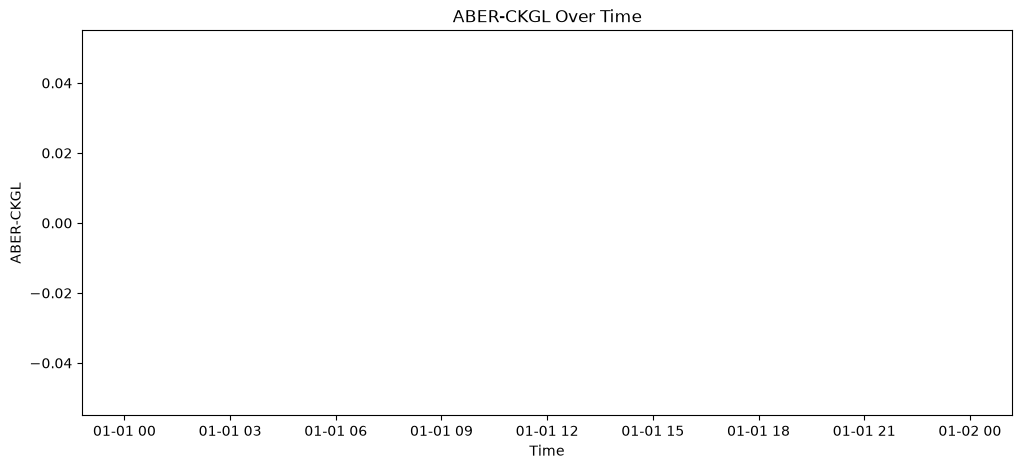

In [25]:
import matplotlib.pyplot as plt

# Select the first numerical sensor.
sensor_to_plot = numerical_data.columns[0]

# Plot the sensor values against time.
plt.figure(figsize=(12, 5))
plt.plot(df.index, df[sensor_to_plot])

# Add labels to make the graph easy to understand.
plt.xlabel("Time")
plt.ylabel(sensor_to_plot)
plt.title(f"{sensor_to_plot} Over Time")

# Display the graph.
plt.show()

## Step 21 — Choose a Sensor That Has Data

Our first numerical column, `ABER-CGKL`, contains only missing values in this recording.

Therefore, there is nothing to plot for this sensor.

Instead of assuming that the first numerical column is usable, we will find the first numerical sensor that contains at least some actual values.

This is a useful habit when working with real-world datasets: always check whether the data you want to analyze is actually available.

In [26]:
# Find numerical columns that have at least one actual value.
sensors_with_data = numerical_data.columns[numerical_data.notna().any()]

# Select the first sensor that contains data.
sensor_to_plot = sensors_with_data[0]

print("Sensor selected for plotting:", sensor_to_plot)

Sensor selected for plotting: ESTADO-DHSV


## Step 22 — Plot a Sensor Over Time

We have now selected a sensor that actually contains data.

Let's plot that sensor against the timestamp.

The horizontal axis represents **time**.

The vertical axis represents the **sensor measurement**.

Each point on the line corresponds to a measurement recorded at a particular time.

This lets us see how the sensor behaves throughout the recording.

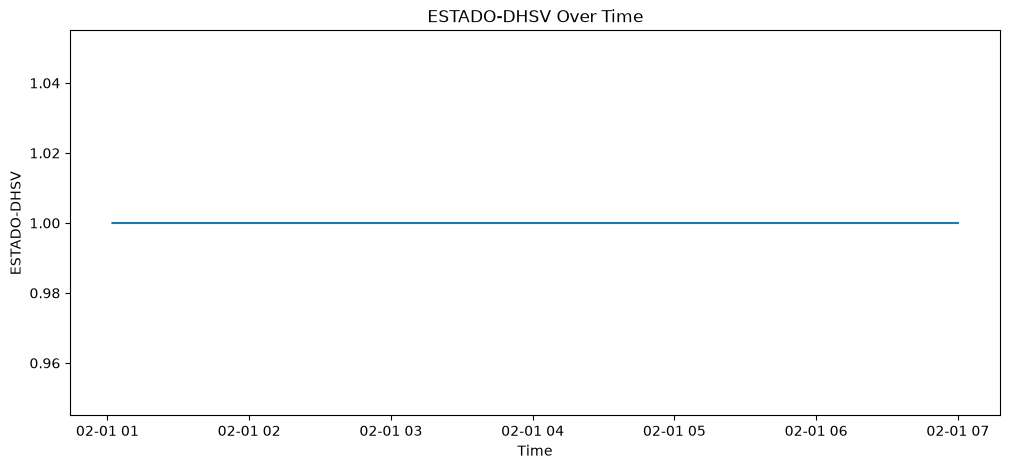

In [27]:
import matplotlib.pyplot as plt

# Plot the selected sensor against time.
plt.figure(figsize=(12, 5))
plt.plot(df.index, df[sensor_to_plot])

# Add labels to the graph.
plt.xlabel("Time")
plt.ylabel(sensor_to_plot)
plt.title(f"{sensor_to_plot} Over Time")

# Display the graph.
plt.show()

## Step 23 — Check How Much the Sensor Changes

The graph looks almost like a straight line.

Instead of relying only on the visual appearance, let's check the actual values.

We will compare the sensor's:

- minimum value
- maximum value
- average value
- standard deviation

The difference between the minimum and maximum tells us the overall range.

The standard deviation tells us how much the values typically vary around the average.

This will tell us whether the sensor is actually changing very little or whether the graph simply makes the changes difficult to see.

In [28]:
# Calculate statistics for the selected sensor.
sensor_min = df[sensor_to_plot].min()
sensor_max = df[sensor_to_plot].max()
sensor_mean = df[sensor_to_plot].mean()
sensor_std = df[sensor_to_plot].std()

print("Sensor:", sensor_to_plot)
print("Minimum:", sensor_min)
print("Maximum:", sensor_max)
print("Average:", sensor_mean)
print("Standard deviation:", sensor_std)

Sensor: ESTADO-DHSV
Minimum: 1.0
Maximum: 1.0
Average: 1.0
Standard deviation: 0.0


## Step 24 — Find Sensors That Actually Vary

Some columns may contain data but still have the same value throughout the entire recording.

For example, `ESTADO-DHSV` contains only `1`, so its standard deviation is `0`.

Such a sensor does not show any variation in this particular recording.

Let's calculate the standard deviation of every numerical column and find the sensors that actually have variation.

This will help us choose a more informative sensor for our time-series plot.

In [29]:
# Calculate the standard deviation of every numerical column.
sensor_variation = numerical_data.std()

# Keep only sensors that actually vary.
varying_sensors = sensor_variation[sensor_variation > 0]

# Sort the sensors from highest variation to lowest variation.
varying_sensors = varying_sensors.sort_values(ascending=False)

# Display the sensors with the most variation first.
print(varying_sensors)

P-MON-CKP     176377.524305
P-ANULAR       45439.941564
P-TPT          21658.437753
P-JUS-CKGL      1249.524899
T-JUS-CKP          0.415988
T-TPT              0.038892
dtype: Float64


## Step 25 — Plot a Sensor With Variation

We found several sensors that actually change during this recording.

Let's use `P-MON-CKP` and plot it over time.

Unlike the previous sensor, this one has variation, so its graph should show changes in the measured value as time passes.

This is closer to what we are interested in for a time-series machine learning problem: understanding how sensor measurements behave and change over time.

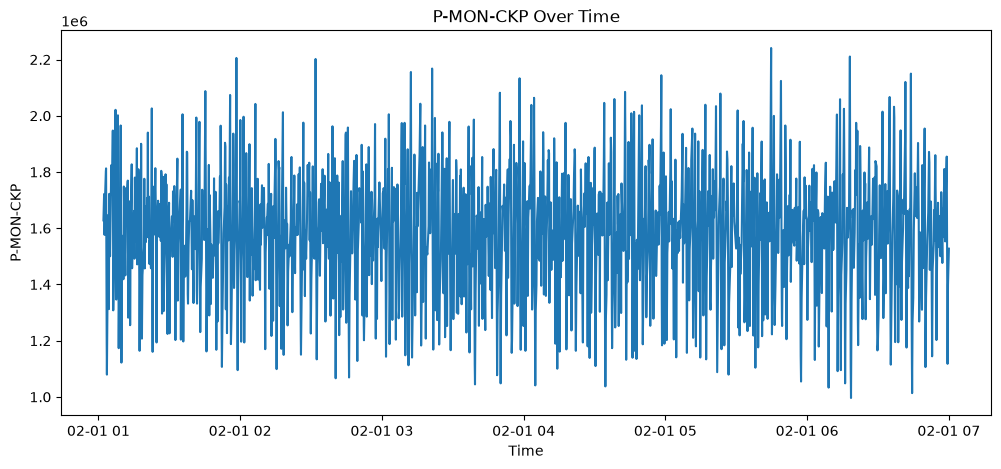

In [30]:
# Select a sensor that has variation.
sensor_to_plot = "P-MON-CKP"

# Plot the sensor values against time.
plt.figure(figsize=(12, 5))
plt.plot(df.index, df[sensor_to_plot])

# Add labels to the graph.
plt.xlabel("Time")
plt.ylabel(sensor_to_plot)
plt.title(f"{sensor_to_plot} Over Time")

# Display the graph.
plt.show()

## Step 26 — Plot All Varying Sensors

We found six sensors that change during this recording.

Instead of plotting them one by one, we can use a `for` loop to repeat the same plotting process for every sensor.

Each sensor will get its own graph.

This is useful for exploration because we can quickly compare how different measurements behave over the same period of time.

We are doing this only to understand the recording visually. Later, we can create more carefully designed visualizations when needed.

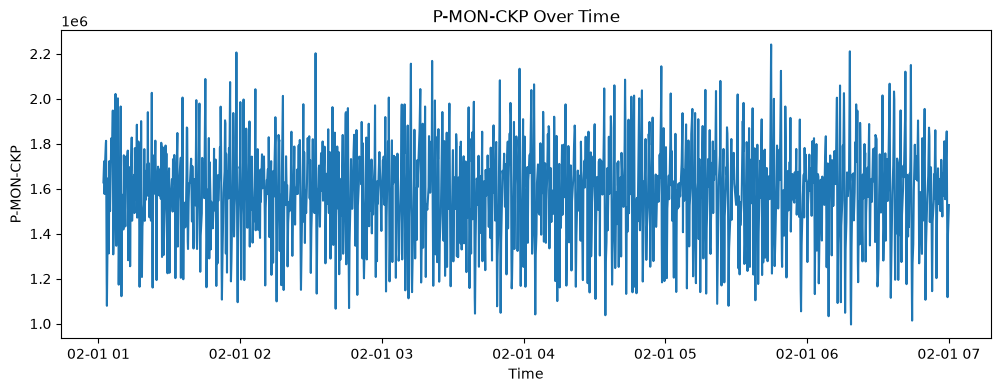

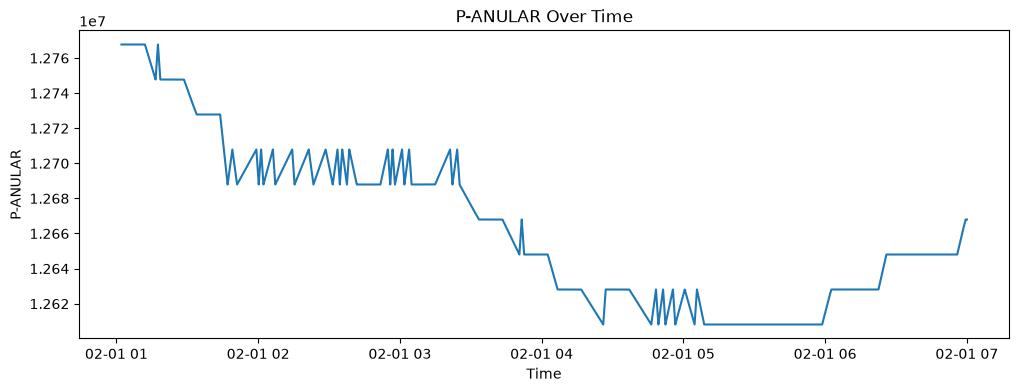

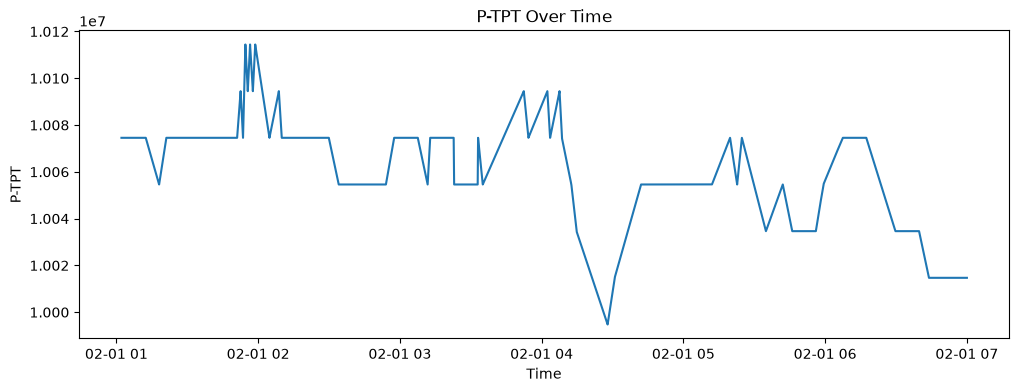

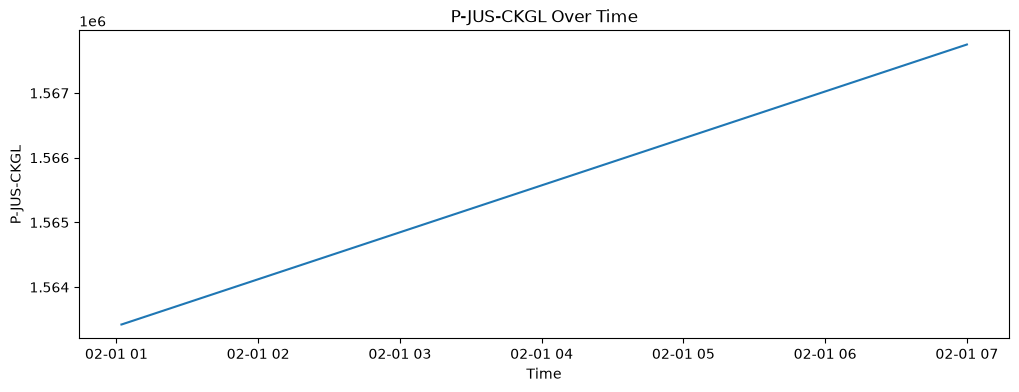

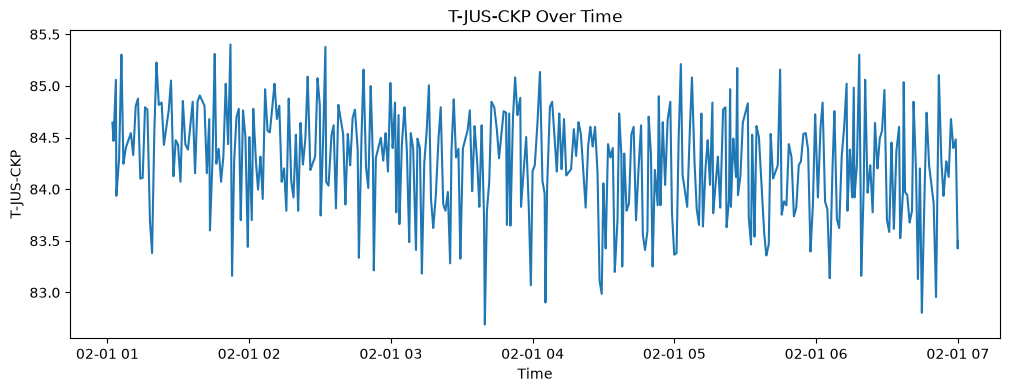

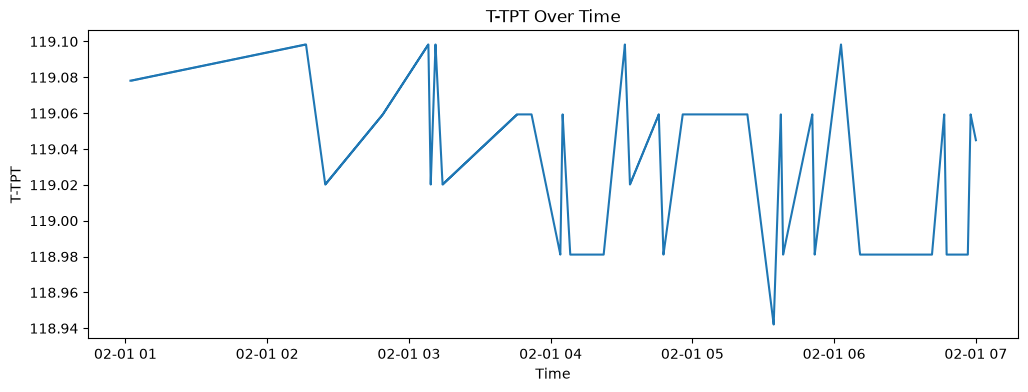

In [31]:
# Plot each sensor that has variation.
for sensor in varying_sensors.index:

    # Create a new figure for the current sensor.
    plt.figure(figsize=(12, 4))

    # Plot the sensor values against time.
    plt.plot(df.index, df[sensor])

    # Add labels to the graph.
    plt.xlabel("Time")
    plt.ylabel(sensor)
    plt.title(f"{sensor} Over Time")

    # Display the graph.
    plt.show()

## Step 27 — Check the Well and Instance Information

We have explored the measurements inside one Parquet file.

Now let's connect this file back to the structure of the 3W dataset.

Each Parquet file represents one **instance (recording)**, and each instance belongs to a particular **well**.

The well information is encoded in the file name.

Let's display the file name so we can see how this particular instance is identified.

In [32]:
# Display the name of the Parquet file we loaded.
print("File name:", first_file.name)

# Display the complete file path.
print("File path:", first_file)

File name: WELL-00001_20170201010207.parquet
File path: c:\Users\Dell\Desktop\Calibrated-Cost-Sensitive-Rare-Event-Detection\data\raw\3W\dataset\0\WELL-00001_20170201010207.parquet


## Step 28 — Extract the Well Name

The filename follows a pattern like:

`WELL-00001_20170201010207.parquet`

Here:

- `WELL-00001` identifies the well.
- `20170201010207` identifies the recording's timestamp in the filename.
- `.parquet` identifies the file format.

Let's extract the well name from the filename.

This is useful because later we may want to compare multiple recordings that came from the same well.

In [33]:
# Get the filename without the .parquet extension.
file_name_without_extension = first_file.stem

# The well name is the part before the first underscore.
well_name = file_name_without_extension.split("_")[0]

print("Well name:", well_name)

Well name: WELL-00001


## Step 29 — Extract the Instance Identifier

The filename contains two important pieces of information:

`WELL-00001_20170201010207.parquet`

We already extracted the well name:

`WELL-00001`

The part after the underscore identifies this particular recording.

Let's extract that part separately.

This helps us understand that a **well can have multiple separate recordings (instances)**.

In [34]:
# Split the filename into the well name and recording identifier.
file_parts = first_file.stem.split("_")

# Extract the recording identifier.
instance_id = file_parts[1]

print("Well:", well_name)
print("Instance identifier:", instance_id)

Well: WELL-00001
Instance identifier: 20170201010207


## Step 30 — Find the Folder of This Instance

We know:

- the **well** this recording came from
- the **instance identifier** of this recording

Now let's find which dataset folder contains this particular file.

The folder number is important because it tells us the **event category associated with this instance**.

For example, a file inside folder `0` belongs to the Normal Operation category, while a file inside folder `1` belongs to the Abrupt Increase of BSW category.

We will get the folder name directly from the file path.

In [35]:
# Get the name of the folder containing this Parquet file.
folder_name = first_file.parent.name

print("Well:", well_name)
print("Instance:", instance_id)
print("Folder:", folder_name)

Well: WELL-00001
Instance: 20170201010207
Folder: 0


## Step 31 — Create an Instance Summary

We have collected several important pieces of information about this recording.

Let's bring them together into one simple summary.

For this instance, we want to know:

- which well it came from
- its instance identifier
- which folder it belongs to
- how many observations it contains
- how long the recording lasted

This gives us a quick overview of one complete recording before we start examining multiple instances.

In [37]:
# Display a summary of the current instance.
print("Well:", well_name)
print("Instance:", instance_id)
print("Folder:", folder_name)
print("Number of observations:", number_of_rows)
print("Recording duration:", recording_duration)

Well: WELL-00001
Instance: 20170201010207
Folder: 0
Number of observations: 21474
Recording duration: 0 days 05:57:53


## Step 32 — Check How Many Instances Came From This Well

We have seen that one Parquet file represents one recording (instance).

Now let's see whether the same well appears in other Parquet files.

This is important because a single well can have **multiple separate recordings**.

We will search through the filenames and count how many Parquet files belong to the same well as our current instance.


In [40]:
# Find all Parquet files whose filename starts with the current well name.
well_files = []

for file_path in parquet_files:
    if file_path.name.startswith(well_name + "_"):
        well_files.append(file_path)

# Count the number of recordings from this well.
number_of_well_instances = len(well_files)

print("Well:", well_name)
print("Number of instances from this well:", number_of_well_instances)

Well: WELL-00001
Number of instances from this well: 132


## Step 33 — See Which Folders This Well Appears In

We know that `WELL-00001` has many separate recordings.

Now let's check **which folders contain those recordings**.

This helps us understand whether the same well can have recordings associated with different event categories.

We will collect the folder number for every recording belonging to this well.

In [42]:
# Get the folder number for every recording from this well.
well_folders = []

for file_path in well_files:
    folder = file_path.parent.name
    well_folders.append(folder)

# Find the unique folders containing this well's recordings.
unique_folders = sorted(set(well_folders))

print("Well:", well_name)
print("Folders containing this well:", unique_folders)

Well: WELL-00001
Folders containing this well: ['0', '1', '3', '4', '7']


## Step 34 — Count This Well's Recordings by Folder

We know which folders contain recordings from this well.

Now let's count **how many separate recordings** from the well are present in each folder.

This will show us how the 132 recordings are distributed across the different categories.

Remember:

**Folder → category of the recording**

It does not mean that all rows inside every recording necessarily have the same `class` value.

In [43]:
# Count how many recordings from this well belong to each folder.
folder_counts = {}

for folder in well_folders:
    if folder not in folder_counts:
        folder_counts[folder] = 0

    folder_counts[folder] += 1

# Display the number of recordings in each folder.
for folder, count in sorted(folder_counts.items()):
    print("Folder", folder, "→", count, "recordings")

Folder 0 → 93 recordings
Folder 1 → 1 recordings
Folder 3 → 1 recordings
Folder 4 → 36 recordings
Folder 7 → 1 recordings


## Step 35 — Map Folder Numbers to Event Names

Until now, we have been referring to the folders only by their numbers.

The 3W dataset gives each folder a specific meaning.

Let's create a simple mapping between the folder number and its event category.

This will make the dataset structure easier to understand when we work with the recordings later.

In [44]:
# Create a mapping between folder numbers and their event categories.
folder_labels = {
    "0": "Normal Operation",
    "1": "Abrupt Increase of BSW",
    "2": "Spurious Closure of DHSV",
    "3": "Severe Slugging",
    "4": "Flow Instability",
    "5": "Rapid Productivity Loss",
    "6": "Quick Restriction in PCK",
    "7": "Scaling in PCK",
    "8": "Hydrate in Production Line",
    "9": "Hydrate in Service Line"
}

# Display the mapping.
for folder, label in folder_labels.items():
    print("Folder", folder, "→", label)

Folder 0 → Normal Operation
Folder 1 → Abrupt Increase of BSW
Folder 2 → Spurious Closure of DHSV
Folder 3 → Severe Slugging
Folder 4 → Flow Instability
Folder 5 → Rapid Productivity Loss
Folder 6 → Quick Restriction in PCK
Folder 7 → Scaling in PCK
Folder 8 → Hydrate in Production Line
Folder 9 → Hydrate in Service Line


## Step 36 — Show the Well's Recordings by Event

We previously counted how many recordings from `WELL-00001` are in each folder.

Now let's combine that information with the event names.

This gives us a more meaningful summary of the recordings from this well.

Instead of seeing:

`Folder 0 → 93`

we can see:

`Normal Operation → 93 recordings`

In [45]:
# Display the recording count using the event names.
for folder, count in sorted(folder_counts.items()):
    
    # Get the event name for this folder.
    event_name = folder_labels[folder]
    
    print(event_name, "→", count, "recordings")

Normal Operation → 93 recordings
Abrupt Increase of BSW → 1 recordings
Severe Slugging → 1 recordings
Flow Instability → 36 recordings
Scaling in PCK → 1 recordings


## Step 37 — Analyze Recording Durations

We have calculated the duration of every recording from `WELL-00001`.

Instead of printing individual durations, let's summarize them.

We will calculate:

- **Minimum duration** → shortest recording
- **Maximum duration** → longest recording
- **Average duration** → typical recording length
- **Median duration** → middle recording length
- **Number of recordings** → total recordings analyzed

This gives us a much better understanding of how long the recordings from this well usually are.

In [48]:
# Convert the durations into seconds so they can be compared mathematically.
duration_in_seconds = [
    duration.total_seconds()
    for duration in well_recording_durations
]

# Calculate summary statistics.
minimum_duration = min(duration_in_seconds)
maximum_duration = max(duration_in_seconds)
average_duration = sum(duration_in_seconds) / len(duration_in_seconds)

# Convert the list into a pandas Series to calculate the median.
duration_series = pd.Series(duration_in_seconds)
median_duration = duration_series.median()

# Display the summary.
print("Well:", well_name)
print("Number of recordings:", len(duration_in_seconds))
print("Shortest recording:", pd.to_timedelta(minimum_duration, unit="s"))
print("Longest recording:", pd.to_timedelta(maximum_duration, unit="s"))
print("Average recording:", pd.to_timedelta(average_duration, unit="s"))
print("Median recording:", pd.to_timedelta(median_duration, unit="s"))

Well: WELL-00001
Number of recordings: 132
Shortest recording: 0 days 02:57:57
Longest recording: 0 days 21:17:12
Average recording: 0 days 05:22:08.613636364
Median recording: 0 days 05:57:51


## Step 38 — See the Duration of Each Recording

The previous step gave us an overall summary for all 132 recordings.

Now let's look at the recordings individually.

For each recording, we will display:

- its instance identifier
- its folder
- its event category
- its duration

This lets us see whether recordings from different event categories have different lengths.

In [49]:
# Display information about each recording from this well.
for file_path in well_files:

    # Load the recording.
    recording = pd.read_parquet(file_path)

    # Get the recording identifier from the filename.
    recording_id = file_path.stem.split("_")[1]

    # Get the folder number.
    folder = file_path.parent.name

    # Get the event name.
    event_name = folder_labels[folder]

    # Calculate the recording duration.
    duration = recording.index.max() - recording.index.min()

    print(
        "Instance:", recording_id,
        "| Folder:", folder,
        "| Event:", event_name,
        "| Duration:", duration
    )

Instance: 20170201010207 | Folder: 0 | Event: Normal Operation | Duration: 0 days 05:57:53
Instance: 20170201060114 | Folder: 0 | Event: Normal Operation | Duration: 0 days 05:58:46
Instance: 20170201110124 | Folder: 0 | Event: Normal Operation | Duration: 0 days 05:58:36
Instance: 20170201160311 | Folder: 0 | Event: Normal Operation | Duration: 0 days 05:56:49
Instance: 20170201210228 | Folder: 0 | Event: Normal Operation | Duration: 0 days 05:57:32
Instance: 20170202020343 | Folder: 0 | Event: Normal Operation | Duration: 0 days 05:56:17
Instance: 20170202070239 | Folder: 0 | Event: Normal Operation | Duration: 0 days 05:57:21
Instance: 20170218000146 | Folder: 0 | Event: Normal Operation | Duration: 0 days 05:58:14
Instance: 20170218050218 | Folder: 0 | Event: Normal Operation | Duration: 0 days 05:57:42
Instance: 20170218100218 | Folder: 0 | Event: Normal Operation | Duration: 0 days 05:57:42
Instance: 20170218150135 | Folder: 0 | Event: Normal Operation | Duration: 0 days 05:58:25

## Step 39 — Understand the `class` Values

We have seen that the `class` column contains different numerical values.

The important thing to understand is that `class` is a **label assigned to each observation (row)**.

It tells us which event or operating condition is associated with that particular timestamp.

However, we should not assume that:

`class = folder number`

For example, a recording inside Folder `4` is associated with the Folder 4 event, but the `class` values inside that recording can change over time.

Let's first see how the `class` value changes throughout our current recording.

In [50]:
# Display the first 100 class values along with their timestamps.
class_over_time = df["class"].head(100)

print(class_over_time) 

timestamp
2017-02-01 01:02:07    <NA>
2017-02-01 01:02:08    <NA>
2017-02-01 01:02:09    <NA>
2017-02-01 01:02:10    <NA>
2017-02-01 01:02:11    <NA>
                       ... 
2017-02-01 01:03:42    <NA>
2017-02-01 01:03:43    <NA>
2017-02-01 01:03:44    <NA>
2017-02-01 01:03:45    <NA>
2017-02-01 01:03:46    <NA>
Name: class, Length: 100, dtype: Int16


## Step 40 — Find the Different `class` Values

Instead of looking at the class values row by row, let's summarize them.

We will find:

- every different value that appears in the `class` column
- how many rows contain each value

We will also include missing values (`<NA>`), because knowing how many labels are missing is important when working with real-world data.

In [52]:
# Count the frequency of every class value.
class_frequencies = df["class"].value_counts(dropna=False)

# Display the different class values and their frequencies.
print(class_frequencies)

class
0       17874
<NA>     3600
Name: count, dtype: Int64


## Step 41 — Find the Different `state` Values

We have seen the different values and frequencies in the `class` column.

Now let's do the same thing for the `state` column.

We will find:

- every different `state` value
- how many rows contain each value
- how many rows have a missing state

This gives us a first look at how `state` is represented in this recording.

In [53]:
# Count the frequency of every state value.
state_frequencies = df["state"].value_counts(dropna=False)

# Display the different state values and their frequencies.
print(state_frequencies)

state
0       17874
<NA>     3600
Name: count, dtype: Int64


## Step 42 — Compare `class` and `state`

For this recording, `class` and `state` appear to have the same values.

Let's directly check whether they are equal for every row where both values are available.

This is a simple sanity check.

If they are equal in this recording, it only tells us about this particular recording. We will not assume that the same relationship exists throughout the entire dataset.

In [54]:
# Find rows where both class and state have values.
both_available = df["class"].notna() & df["state"].notna()

# Compare class and state only where both are available.
class_state_match = (
    df.loc[both_available, "class"]
    == df.loc[both_available, "state"]
)

# Count how many rows match and do not match.
number_of_matches = class_state_match.sum()
number_of_differences = (~class_state_match).sum()

print("Rows where both are available:", len(class_state_match))
print("Matching values:", number_of_matches)
print("Different values:", number_of_differences)

Rows where both are available: 17874
Matching values: 17874
Different values: 0


## Step 43 — Inspect an Event Recording

The recording we have been studying came from Folder 0, which represents Normal Operation.

Now let's choose a recording from an event folder.

We will use Folder 1, which represents:

**Abrupt Increase of BSW**

We will load one recording from this folder and examine its `class` values.

This lets us compare the label information in a normal recording with an event recording.

In [55]:
# Get the Parquet files from Folder 1.
folder_1_files = list((dataset_path / "1").glob("*.parquet"))

# Select the first recording from Folder 1.
event_file = folder_1_files[0]

# Load the event recording.
event_df = pd.read_parquet(event_file)

# Count the different class values in this recording.
event_class_frequencies = event_df["class"].value_counts(dropna=False)

print("Event file:", event_file.name)
print("Class frequencies:")
print(event_class_frequencies)

Event file: DRAWN_00001.parquet
Class frequencies:
class
101    148616
0       13779
1       10405
Name: count, dtype: Int64


## Step 39 — See When Each Class Appears

We have now selected an event recording from Folder 1:

`DRAWN_00001.parquet`

We previously found that this recording contains several `class` values:

- `0`
- `1`
- `101`

Now let's see **when each class appears during the recording**.

For each class, we will find:

- the first timestamp where it appears
- the last timestamp where it appears
- the number of rows belonging to that class

This will help us understand how the `class` value changes throughout the simulated recording.

In [58]:
# Get all class values that are actually present in the recording.
event_class_values = event_df["class"].dropna().unique()

# Check each class separately.
for class_value in sorted(event_class_values):

    # Select the rows belonging to the current class.
    class_rows = event_df[event_df["class"] == class_value]

    # Find when this class first and last appears.
    first_timestamp = class_rows.index.min()
    last_timestamp = class_rows.index.max()

    # Count how many rows have this class.
    number_of_rows = len(class_rows)

    print("Class:", class_value)
    print("First timestamp:", first_timestamp)
    print("Last timestamp:", last_timestamp)
    print("Number of rows:", number_of_rows)
    print()

Class: 0
First timestamp: 2018-09-05 20:44:36
Last timestamp: 2018-09-06 00:34:14
Number of rows: 13779

Class: 1
First timestamp: 2018-09-07 17:51:11
Last timestamp: 2018-09-07 20:44:35
Number of rows: 10405

Class: 101
First timestamp: 2018-09-06 00:34:15
Last timestamp: 2018-09-07 17:51:10
Number of rows: 148616



## Step 40 — Visualize Class Changes Over Time

We have seen the timestamps at which each class appears.

Now let's visualize the `class` value over the entire recording.

The horizontal axis will represent **time**.

The vertical axis will represent the **class value**.

This will allow us to visually see when the recording changes from one class to another.

We are not analyzing sensor behaviour yet. We are only trying to understand how the target label changes throughout a single recording.

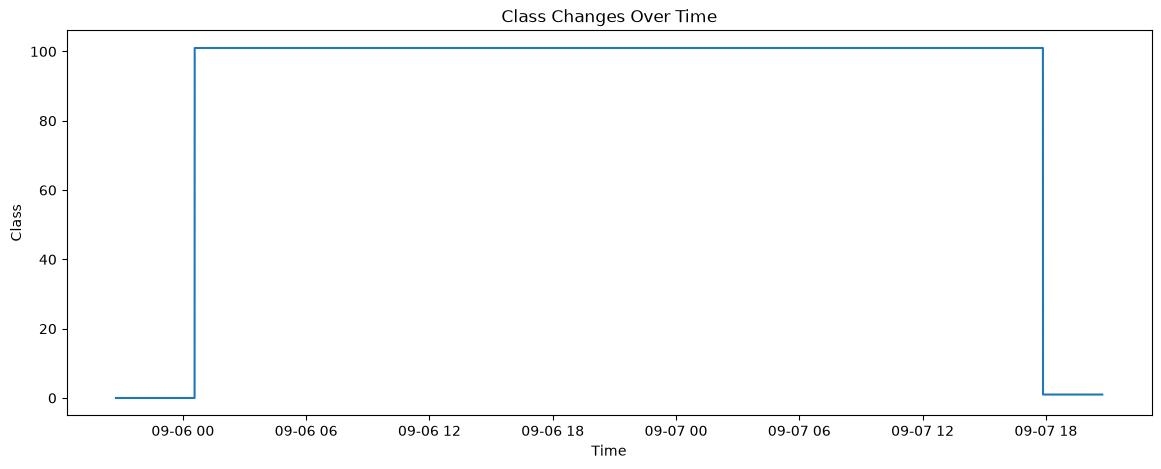

In [60]:
# Plot the class value over time.
plt.figure(figsize=(14, 5))

plt.plot(event_df.index, event_df["class"])

# Add labels to the graph.
plt.xlabel("Time")
plt.ylabel("Class")
plt.title("Class Changes Over Time")

# Display the graph.
plt.show()

# THE BELOW GRAPH IS MISLEADING BECUASE Y-AXIS HAS VALUES FROM 0-100 WHICH DOES NOT EXIST IN DATA -> THIS 
# HAPPENS BECAUSE THIS IS A CONTINUOUS PLOT, SO WE HAVE TO CHANGE IT TO A STEP-PLOT

## Step 41 — Visualize Class Changes Over Time

We have seen the timestamps at which each class appears.

Now let's visualize the `class` value over the entire recording.

The horizontal axis represents **time**.

The vertical axis represents the **class value**.

Because `class` represents categories rather than a continuously changing numerical measurement, we should not connect different class values with a diagonal or vertical line.

Instead, we will use a **step plot**.

A step plot keeps the class value constant until the moment the class changes, making the transitions between classes easier to understand.

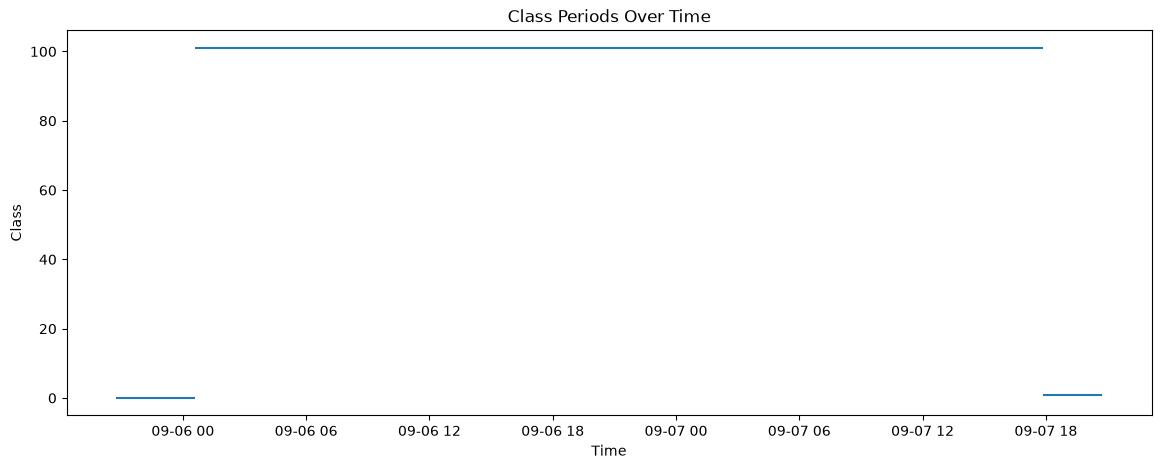

In [62]:
# Get the class values that appear in the recording.
class_values = sorted(event_df["class"].dropna().unique())

# Create a new figure.
plt.figure(figsize=(14, 5))

# Plot each class as a separate horizontal segment.
for class_value in class_values:

    # Select all rows belonging to this class.
    class_rows = event_df[event_df["class"] == class_value]

    # Find the first and last timestamp for this class.
    first_timestamp = class_rows.index.min()
    last_timestamp = class_rows.index.max()

    # Draw only the horizontal period for this class.
    plt.hlines(
        y=class_value,
        xmin=first_timestamp,
        xmax=last_timestamp
    )

# Add labels to the graph.
plt.xlabel("Time")
plt.ylabel("Class")
plt.title("Class Periods Over Time")

# Display the graph.
plt.show()

## Step 42 — Understand the `state` Values

We have now seen how the `class` value changes over time.

The 3W dataset also contains another label called `state`.

`class` and `state` are both recorded for each observation, but they represent different information.

Before trying to interpret what every state number means, let's first inspect how `state` changes throughout the same event recording.

We will:

- find the different `state` values present
- find when each state appears
- count how many observations belong to each state

For now, we are only observing the data. We will interpret the meaning of the state values separately.

In [63]:
# Find the different state values in the event recording.
event_state_values = event_df["state"].dropna().unique()

# Check each state separately.
for state_value in sorted(event_state_values):

    # Select the rows belonging to the current state.
    state_rows = event_df[event_df["state"] == state_value]

    # Find when this state first and last appears.
    first_timestamp = state_rows.index.min()
    last_timestamp = state_rows.index.max()

    # Count how many rows have this state.
    number_of_rows = len(state_rows)

    print("State:", state_value)
    print("First timestamp:", first_timestamp)
    print("Last timestamp:", last_timestamp)
    print("Number of rows:", number_of_rows)
    print()

State: 0
First timestamp: 2018-09-05 20:44:36
Last timestamp: 2018-09-07 20:44:35
Number of rows: 172800



## Step 43 — Compare `class` and `state`

We have now inspected both labels in the same recording.

The results are:

- `class` changes during the recording.
- `state` remains `0` for the entire recording.

Let's compare them directly for every observation.

This will help us see whether `class` and `state` usually contain the same value or whether they provide different information.

We are still only examining this particular recording. We will study the broader meaning of `class` and `state` later.

In [64]:
# Create a comparison between the class and state columns.
class_state_comparison = event_df[["class", "state"]]

# Count the different combinations of class and state.
combination_counts = class_state_comparison.value_counts(dropna=False)

# Display the combinations and their frequencies.
print(combination_counts)

class  state
101    0        148616
0      0         13779
1      0         10405
Name: count, dtype: int64


## Step 44 — See the Class Transition Times

We know that the `class` changes in this recording:

`0 → 101 → 1`

We also know exactly when those changes happen.

Let's calculate the timestamps at which the class changes.

To do this, we will compare each row's `class` with the previous row's `class`.

Whenever the value is different, a class transition has occurred.

This is useful because our machine learning problem is about detecting changes in system behaviour from time-series sensor data.

In [65]:
# Compare each class value with the previous row.
class_changed = event_df["class"] != event_df["class"].shift(1)

# Keep only the rows where the class changed.
class_transition_rows = event_df[class_changed]

# Display the timestamps and class values at the transitions.
print(class_transition_rows[["class", "state"]])

                     class  state
timestamp                        
2018-09-06 00:34:15    101      0
2018-09-07 17:51:11      1      0


## Step 45 — Calculate the Duration of Each Class Period

We know when each class begins and ends.

Now let's calculate how long the recording spent in each class.

For each class period, we will calculate its duration using:

`last timestamp - first timestamp`

This will let us compare how much time the simulated recording spent in each class.

In [66]:
# Calculate the duration of each class period.
for class_value in sorted(event_class_values):

    # Select all rows belonging to the current class.
    class_rows = event_df[event_df["class"] == class_value]

    # Find the first and last timestamp.
    first_timestamp = class_rows.index.min()
    last_timestamp = class_rows.index.max()

    # Calculate the duration of this class period.
    class_duration = last_timestamp - first_timestamp

    print("Class:", class_value)
    print("Duration:", class_duration)
    print()

Class: 0
Duration: 0 days 03:49:38

Class: 1
Duration: 0 days 02:53:24

Class: 101
Duration: 1 days 17:16:55



## Step 46 — Understand the Order of Classes

We have calculated how long each class lasts.

Now let's put the classes in the order in which they actually occurred.

For this recording, the sequence is:

`Class 0 → Class 101 → Class 1`

This is important because a time-series dataset is not just a collection of independent rows.

The **order of observations matters**.

The sensor measurements before the event, during the transition, and during the event occur at different points in time.

This is one of the key ideas we need to remember when we eventually prepare the data for machine learning.

In [67]:
# Find the first timestamp at which each class appears.
class_start_times = {}

for class_value in event_class_values:

    # Select all rows belonging to the current class.
    class_rows = event_df[event_df["class"] == class_value]

    # Store the first timestamp for this class.
    class_start_times[class_value] = class_rows.index.min()

# Sort the classes by when they first appeared.
classes_in_time_order = sorted(
    class_start_times,
    key=class_start_times.get
)

# Display the classes in chronological order.
for class_value in classes_in_time_order:
    print(
        "Class:",
        class_value,
        "→ Starts at:",
        class_start_times[class_value]
    )

Class: 0 → Starts at: 2018-09-05 20:44:36
Class: 101 → Starts at: 2018-09-06 00:34:15
Class: 1 → Starts at: 2018-09-07 17:51:11


## Step 47 — Check Whether the Class Changes Only Twice

We identified two class transition timestamps.

Now let's verify the total number of class transitions directly from the data.

We will count every time the `class` value is different from the previous observation.

If the result is `2`, it confirms that this recording contains exactly two class transitions:

`0 → 101`

and

`101 → 1`

In [68]:
# Compare every class value with the previous observation.
class_changes = event_df["class"] != event_df["class"].shift(1)

# Count how many times the class changed.
number_of_class_changes = class_changes.sum()

print("Number of class transitions:", number_of_class_changes)

Number of class transitions: 2


## Step 48 — Investigate the Special `class` Value

In the simulated recording, we found three class values:

- `0`
- `1`
- `101`

We already understand that `0` and `1` are different class labels in this recording.

However, `101` is a special value that we should not interpret simply as another event class.

Before using this dataset for machine learning, we need to understand what these special class values mean according to the 3W dataset documentation.

For now, we will identify `101` as a value that requires special handling and avoid making assumptions about it from the number alone.

In [69]:
# Display all unique class values in this recording.
unique_class_values = event_df["class"].dropna().unique()

print("Unique class values:", sorted(unique_class_values))

Unique class values: [np.int16(0), np.int16(1), np.int16(101)]


## Step 49 — Summarize What We Observed in This Instance

We have now examined the structure, timing, labels, and class transitions
of `DRAWN_00001.parquet`.

For this particular instance, we found:

- The recording contains 172,800 observations.
- The `class` values are `0`, `101`, and `1`.
- The class sequence is `0 → 101 → 1`.
- There are two class transitions.
- The `state` value is `0` throughout the entire recording.
- Therefore, `class` and `state` are providing different information in
  this instance.

We will not assign our own meaning to the special value `101` yet.
Its meaning and handling will be determined from the 3W dataset
specification during preprocessing.

In [70]:
# Display a compact summary of the instance we just studied.
print("Instance:", event_file.name)
print("Number of observations:", len(event_df))
print("Class values:", sorted(event_df["class"].dropna().unique()))
print("State values:", sorted(event_df["state"].dropna().unique()))
print("Number of class transitions:", number_of_class_changes)

Instance: DRAWN_00001.parquet
Number of observations: 172800
Class values: [np.int16(0), np.int16(1), np.int16(101)]
State values: [np.int16(0)]
Number of class transitions: 2


## Step 50 — Check the Number of Sensor Variables

We have examined the labels and one complete recording.

Before finishing the dataset exploration, let's confirm how many sensor and operational variables are available.

The DataFrame also contains `class` and `state`, so we will separate those two label columns from the sensor/operational columns.

This gives us the feature set that we will eventually work with when preparing the data for machine learning.

In [71]:
# Create a list of the sensor and operational columns.
sensor_columns = [
    column
    for column in event_df.columns
    if column not in ["class", "state"]
]

# Count the sensor and operational variables.
number_of_sensors = len(sensor_columns)

print("Number of sensor/operational variables:", number_of_sensors)

# Display their names.
print("\nSensor/operational variables:")
for sensor in sensor_columns:
    print(sensor)

Number of sensor/operational variables: 27

Sensor/operational variables:
ABER-CKGL
ABER-CKP
ESTADO-DHSV
ESTADO-M1
ESTADO-M2
ESTADO-PXO
ESTADO-SDV-GL
ESTADO-SDV-P
ESTADO-W1
ESTADO-W2
ESTADO-XO
P-ANULAR
P-JUS-BS
P-JUS-CKGL
P-JUS-CKP
P-MON-CKGL
P-MON-CKP
P-MON-SDV-P
P-PDG
PT-P
P-TPT
QBS
QGL
T-JUS-CKP
T-MON-CKP
T-PDG
T-TPT


## Step 51 — Check Sensor Availability in This Instance

The 3W dataset provides 27 sensor and operational variables.

However, a sensor does not necessarily contain measurements in every recording.

For this particular instance, let's check how many observations are actually available for each sensor.

This will help us understand an important characteristic of real-world sensor data:

**A variable can exist in the dataset but still be completely or partially missing in a particular recording.**

We will compare the number of available observations with the total number of observations.

In [72]:
# Count the available (non-missing) observations for each sensor.
available_sensor_values = event_df[sensor_columns].notna().sum()

# Create a table showing available and missing observations.
sensor_availability = pd.DataFrame({
    "Available": available_sensor_values,
    "Missing": len(event_df) - available_sensor_values
})

# Display the sensor availability.
print(sensor_availability)

               Available  Missing
ABER-CKGL              0   172800
ABER-CKP               0   172800
ESTADO-DHSV            0   172800
ESTADO-M1              0   172800
ESTADO-M2              0   172800
ESTADO-PXO             0   172800
ESTADO-SDV-GL          0   172800
ESTADO-SDV-P           0   172800
ESTADO-W1              0   172800
ESTADO-W2              0   172800
ESTADO-XO              0   172800
P-ANULAR               0   172800
P-JUS-BS               0   172800
P-JUS-CKGL             0   172800
P-JUS-CKP              0   172800
P-MON-CKGL             0   172800
P-MON-CKP         172800        0
P-MON-SDV-P            0   172800
P-PDG             172800        0
PT-P                   0   172800
P-TPT             172800        0
QBS                    0   172800
QGL                    0   172800
T-JUS-CKP         172800        0
T-MON-CKP              0   172800
T-PDG                  0   172800
T-TPT             172800        0


## Step 52 — Identify Completely Missing Sensors

The previous step showed that not all 27 sensor variables contain data in this recording.

Some sensors have measurements for all 172,800 observations, while other sensors are completely missing.

Let's separate the sensors into two groups:

- **Available sensors** → contain at least one measurement
- **Completely missing sensors** → contain no measurements at all

This distinction will become important during preprocessing because we cannot use a sensor as a machine learning feature if it contains no data in the recordings we are using.

In [73]:
# Find sensors that contain at least one available value.
available_sensors = []

# Find sensors that contain no available values.
completely_missing_sensors = []

# Check every sensor.
for sensor in sensor_columns:

    # Check whether the sensor contains at least one non-missing value.
    has_data = event_df[sensor].notna().any()

    if has_data:
        available_sensors.append(sensor)
    else:
        completely_missing_sensors.append(sensor)

# Display the results.
print("Available sensors:", len(available_sensors))
print(available_sensors)

print("\nCompletely missing sensors:", len(completely_missing_sensors))
print(completely_missing_sensors)

Available sensors: 5
['P-MON-CKP', 'P-PDG', 'P-TPT', 'T-JUS-CKP', 'T-TPT']

Completely missing sensors: 22
['ABER-CKGL', 'ABER-CKP', 'ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-ANULAR', 'P-JUS-BS', 'P-JUS-CKGL', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-SDV-P', 'PT-P', 'QBS', 'QGL', 'T-MON-CKP', 'T-PDG']


## Step 53 — Check Whether the Available Sensors Are Complete

We found that only 5 of the 27 sensors contain data in this recording.

Now let's check whether those 5 available sensors are actually complete.

A sensor may contain some data but still have missing values at certain timestamps.

So we will calculate the percentage of missing values for the available sensors.

If the percentage is `0%`, that sensor has a measurement at every timestamp in this recording.

In [74]:
# Calculate the percentage of missing values for the available sensors.
available_sensor_missing_percentage = (
    event_df[available_sensors].isna().sum() / len(event_df)
) * 100

# Display the missing-value percentage.
print(available_sensor_missing_percentage)

P-MON-CKP    0.0
P-PDG        0.0
P-TPT        0.0
T-JUS-CKP    0.0
T-TPT        0.0
dtype: float64


## Step 54 — Check the Size of the Instance

Before finishing our dataset exploration, let's put the main numbers
of this instance together.

We will check:

- total observations
- total sensor/operational variables
- available sensors 
- completely missing sensors
- class values
- state values

This gives us one final structural summary of the recording

In [75]:
# Display the main structural information about this instance.
print("Instance:", event_file.name)
print("Total observations:", len(event_df))
print("Total sensor/operational variables:", len(sensor_columns))
print("Available sensors:", len(available_sensors))
print("Completely missing sensors:", len(completely_missing_sensors))
print("Class values:", sorted(event_df["class"].dropna().unique()))
print("State values:", sorted(event_df["state"].dropna().unique()))

Instance: DRAWN_00001.parquet
Total observations: 172800
Total sensor/operational variables: 27
Available sensors: 5
Completely missing sensors: 22
Class values: [np.int16(0), np.int16(1), np.int16(101)]
State values: [np.int16(0)]


## Step 55 — Check the Time Range of the Instance

We have examined the rows, sensors, classes, and states.

One final useful check is to look at the complete time range covered by this instance.

We will display:

- the first timestamp
- the last timestamp
- the total duration

This confirms that all 172,800 observations belong to one continuous time-series recording.

In [76]:
# Get the first and last timestamps of the instance.
instance_start_time = event_df.index.min()
instance_end_time = event_df.index.max()

# Calculate the total duration.
instance_duration = instance_end_time - instance_start_time

# Display the time range.
print("Instance:", event_file.name)
print("Start time:", instance_start_time)
print("End time:", instance_end_time)
print("Duration:", instance_duration)

Instance: DRAWN_00001.parquet
Start time: 2018-09-05 20:44:36
End time: 2018-09-07 20:44:35
Duration: 1 days 23:59:59


## Step 56 — Final Takeaways From the 3W Dataset

We have now explored the structure of the 3W dataset and examined one
complete simulated/drawn recording in detail.

The main things we learned are:

### Dataset structure

- The dataset is divided into folders representing different event categories.
- Each Parquet file represents one separate recording (instance).
- A well can have multiple separate recordings.
- Not every instance is necessarily associated with a physical well.
- The filename can indicate whether an instance is `WELL`, `DRAWN`, or `SIMULATED`.

### Time-series structure

- Each row represents an observation at a particular timestamp.
- The timestamp is stored as the DataFrame index.
- Observations are ordered chronologically.
- Different recordings can have different durations.

### Sensor data

- The dataset provides 27 sensor/operational variables.
- A particular instance may not contain data for every sensor.
- Some sensors can be completely missing for an entire instance.

### Labels

- `class` and `state` are separate columns.
- Their values can change or remain constant depending on the instance.
- In the instance we studied, `class` changed from `0 → 101 → 1`.
- In the same instance, `state` remained `0`.

### Important Observation

The 3W dataset is not simply a normal table where every row is an
independent observation.

It is **time-series data made up of many separate recordings**, where
sensor measurements and labels are observed over time.

Understanding this structure is essential before we begin preprocessing
the data for our machine learning project.

In [77]:
# Confirm that the notebook is working with a time-series DataFrame.
print("Dataset structure confirmed.")
print()
print("Rows in current instance:", len(event_df))
print("Sensor/operational variables:", len(sensor_columns))
print("Class column present:", "class" in event_df.columns)
print("State column present:", "state" in event_df.columns)
print("Timestamp index:", event_df.index.name)

Dataset structure confirmed.

Rows in current instance: 172800
Sensor/operational variables: 27
Class column present: True
State column present: True
Timestamp index: timestamp
